In [1]:
import torch
import torch.nn as nn

import numpy as np
import math

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MultipleLocator
import matplotlib.cm as cm
from matplotlib.cm import get_cmap

import copy
import seaborn as sns

import tqdm
import pickle

# MI estimators
# from utils.estimators import *

In [2]:
def import_data(num_policy:int , case:str, level_list:list):
    dataset = {}
    for level in level_list:
        for policy in range(num_policy):
            dataset[level] = (np.load(f"../data/cpg_rbf_hebb/{case}-ALPHA{level}-{policy}.npy" , allow_pickle=True).item())
    return dataset

In [3]:
NUM_POLICY = 1
level_list = [0.1 , 0.2 ,0.3 ,0.4 , 0.5 ,0.6 , 0.7,0.8,0.9,1.0]

normal= import_data(num_policy=NUM_POLICY, case="normal", level_list=level_list)
loss = import_data(num_policy=NUM_POLICY, case="loss", level_list=level_list)
pos_loss = import_data(num_policy=NUM_POLICY, case="pos_loss", level_list=level_list)
act_loss = import_data(num_policy=NUM_POLICY, case="act_loss", level_list=level_list)
fc_loss = import_data(num_policy=NUM_POLICY, case="fc_loss", level_list=level_list)

morph = import_data(num_policy=NUM_POLICY, case="morph", level_list=level_list)

cases = ["normal" , "loss" , "morph" , "pos_loss" , "act_loss" , "fc_loss"]
# [case:str][number_file:int][data/brain:str]

In [4]:
robot = 5

# Displacement
performance = {case : {alpha : [] for alpha in level_list} for case in cases}
for level in level_list:
    for i in range(robot):
        performance["normal"][level].append(np.max(normal[level]["data"]["pos_x"][:,i]))
        performance["loss"][level].append(np.max(loss[level]["data"]["pos_x"][:,i]))
        performance["pos_loss"][level].append(np.max(pos_loss[level]["data"]["pos_x"][:,i]))
        performance["act_loss"][level].append(np.max(act_loss[level]["data"]["pos_x"][:,i]))
        performance["fc_loss"][level].append(np.max(fc_loss[level]["data"]["pos_x"][:,i]))
        performance["morph"][level].append(np.max(morph[level]["data"]["pos_x"][:,i]))

In [5]:
# Cost of Transport (COT)
cot = {case : {alpha : [] for alpha in level_list} for case in cases}
for level in level_list:
    for i in range(robot):
        for case in cases:
            cot["normal"][level].append(
                np.sum(normal[level]["data"]["dof_vel"][:,i,:] * normal[level]["data"]["torque"][:,i,:])*0.02 /
                (np.average(normal[level]["data"]["vel_w"][:,i,0])*2.1*9.81)
                )
            cot["loss"][level].append(
                np.sum(loss[level]["data"]["dof_vel"][:,i,:] * loss[level]["data"]["torque"][:,i,:])*0.02 /
                (np.average(loss[level]["data"]["vel_w"][:,i,0])*2.1*9.81)
                )
            cot["pos_loss"][level].append(
                np.sum(pos_loss[level]["data"]["dof_vel"][:,i,:] * pos_loss[level]["data"]["torque"][:,i,:])*0.02 /
                (np.average(pos_loss[level]["data"]["vel_w"][:,i,0])*2.1*9.81)
                )
            cot["act_loss"][level].append(
                np.sum(act_loss[level]["data"]["dof_vel"][:,i,:] * act_loss[level]["data"]["torque"][:,i,:])*0.02 /
                (np.average(act_loss[level]["data"]["vel_w"][:,i,0])*2.1*9.81)
                )
            cot["fc_loss"][level].append(
                np.sum(fc_loss[level]["data"]["dof_vel"][:,i,:] * fc_loss[level]["data"]["torque"][:,i,:])*0.02 /
                (np.average(fc_loss[level]["data"]["vel_w"][:,i,0])*2.1*9.81)
                )
            cot["morph"][level].append(
                np.sum(morph[level]["data"]["dof_vel"][:,i,:] * morph[level]["data"]["torque"][:,i,:])*0.02 /
                (np.average(morph[level]["data"]["vel_w"][:,i,0])*2.1*9.81)
                )

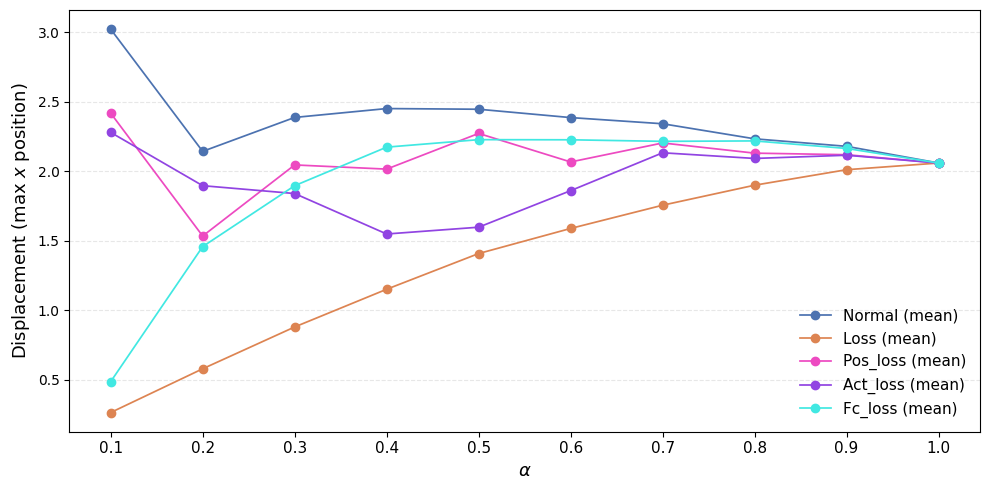

In [6]:
alphas = sorted(level_list)
x = np.arange(len(alphas))
width = 0.8
cases = ["normal" , "loss" , "pos_loss" , "act_loss" , "fc_loss"]

colors = {
    "normal": "#4C72B0",  # blue
    "loss":   "#DD8452",  # orange
    "morph":  "#55A868",  # green
    "pos_loss" : "#ED4AC1",
    "act_loss" : "#9144E2",
    "fc_loss" : "#41E8E2"

}

fig, ax = plt.subplots(figsize=(10, 5))

for j, case in enumerate(cases):
    data = [performance[case][a] for a in alphas]
    means = [np.mean(d) for d in data]
    positions = x  #* width
    # bp = ax.boxplot(
    #     data,
    #     positions=positions,
    #     widths=0.22,
    #     patch_artist=True,
    #     showfliers=False,
    #     medianprops=dict(color="black", linewidth=2),
    #     whiskerprops=dict(linewidth=1.2),
    #     capprops=dict(linewidth=1.2),
    # )
    # # set box color
    # for box in bp["boxes"]:
    #     box.set_facecolor(colors[case])
    #     box.set_alpha(0.35)
    #     box.set_edgecolor(colors[case])
    #     box.set_linewidth(1.5)
    # mean line
    ax.plot(positions, means, marker='o', linewidth=1.25, color=colors[case], label=f"{case.capitalize()} (mean)")
# axis & labels
ax.set_xticks(x)
ax.set_xticklabels([str(a) for a in alphas], fontsize=11)
ax.set_xlabel(r"$\alpha$", fontsize=13)
ax.set_ylabel("Displacement (max $x$ position)", fontsize=13)
# grid & style
ax.grid(True, axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

# legend
ax.legend(frameon=False, fontsize=11, loc="lower right")

plt.tight_layout()
plt.show()

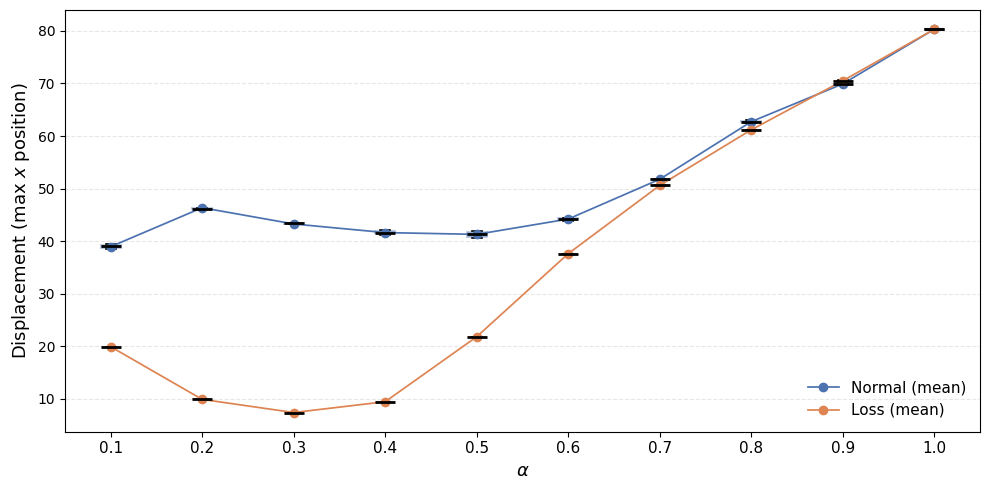

In [7]:
alphas = sorted(level_list)
x = np.arange(len(alphas))
width = 0.8
cases = ["normal" , "loss"]

colors = {
    "normal": "#4C72B0",  # blue
    "loss":   "#DD8452",  # orange
    "morph":  "#55A868",  # green
}

fig, ax = plt.subplots(figsize=(10, 5))

for j, case in enumerate(cases):
    data = [cot[case][a] for a in alphas]
    means = [np.mean(d) for d in data]
    positions = x  #* width
    bp = ax.boxplot(
        data,
        positions=positions,
        widths=0.22,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black", linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
    )
    # set box color
    for box in bp["boxes"]:
        box.set_facecolor(colors[case])
        box.set_alpha(0.35)
        box.set_edgecolor(colors[case])
        box.set_linewidth(1.5)
    # mean line
    ax.plot(positions, means, marker='o', linewidth=1.25, color=colors[case], label=f"{case.capitalize()} (mean)")
# axis & labels
ax.set_xticks(x)
ax.set_xticklabels([str(a) for a in alphas], fontsize=11)
ax.set_xlabel(r"$\alpha$", fontsize=13)
ax.set_ylabel("Displacement (max $x$ position)", fontsize=13)
# grid & style
ax.grid(True, axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

# legend
ax.legend(frameon=False, fontsize=11, loc="lower right")

plt.tight_layout()
plt.show()